In [1]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import warnings
from astropy.wcs import WCS
from astropy.io import fits
from scipy.optimize import curve_fit, root_scalar
from spectral_cube import SpectralCube
from lmfit import Model, Parameters
from scipy.interpolate import interp1d
from scipy.signal import find_peaks

In [2]:
# File paths
path = '/home/scratch/hfwest/RAMPS/'
outdir = path+'Results/'
suffixout='10sig'
Cube = SpectralCube.read(path + 'Data/L28_5_NH3_1-1_cube.fits').with_spectral_unit(u.km/u.s)
prefixout = 'L28_5_NH3_1-1'
print(Cube.shape)

(854, 520, 598)


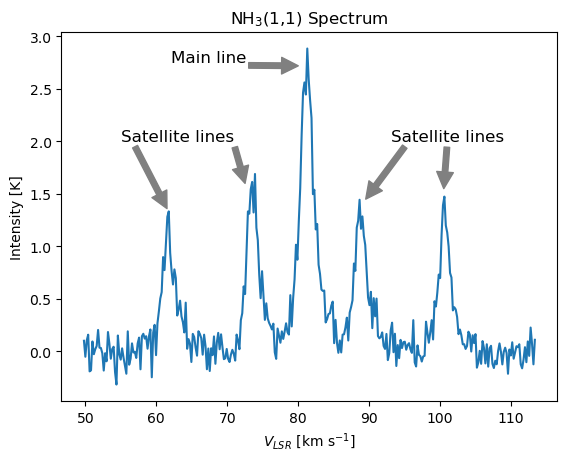

In [3]:
plt.plot(Cube.spectral_axis[400:720], Cube[:, 320, 396][400:720])
plt.title('NH$_3$(1,1) Spectrum')
plt.ylabel('Intensity [K]')
plt.xlabel('$V_{LSR}$ [km s$^{-1}$]')

# Center
plt.annotate('Main line', [80, 2.72], [62, 2.753], arrowprops=dict(color='gray'), fontsize='large')

# Left side
plt.annotate('Satellite lines', [72.5, 1.6], [55, 2], arrowprops=dict(color='gray'), fontsize='large')
plt.annotate('', [61.5, 1.36], [57, 1.95], arrowprops=dict(color='gray'))

# Right side
plt.annotate('Satellite lines', [100.5, 1.55], [93, 2], arrowprops=dict(color='gray'), fontsize='large')
plt.annotate('', [89.5, 1.45], [95, 1.95], arrowprops=dict(color='gray'))

plt.savefig('/users/hfwest/GBO-REU/Plots/New-Example-Spectrum.png')
plt.show()


In [6]:
Cube = SpectralCube.read('/home/scratch/hfwest/Pilot/Data/Pilot_NH3_11_bl.fits').with_spectral_unit(u.km/u.s, velocity_convention = 'radio')
model = SpectralCube.read('/home/scratch/hfwest/Pilot/Results/Pilot_NH3_11_Fit3sig.fits').with_spectral_unit(u.km/u.s, velocity_convention = 'radio')

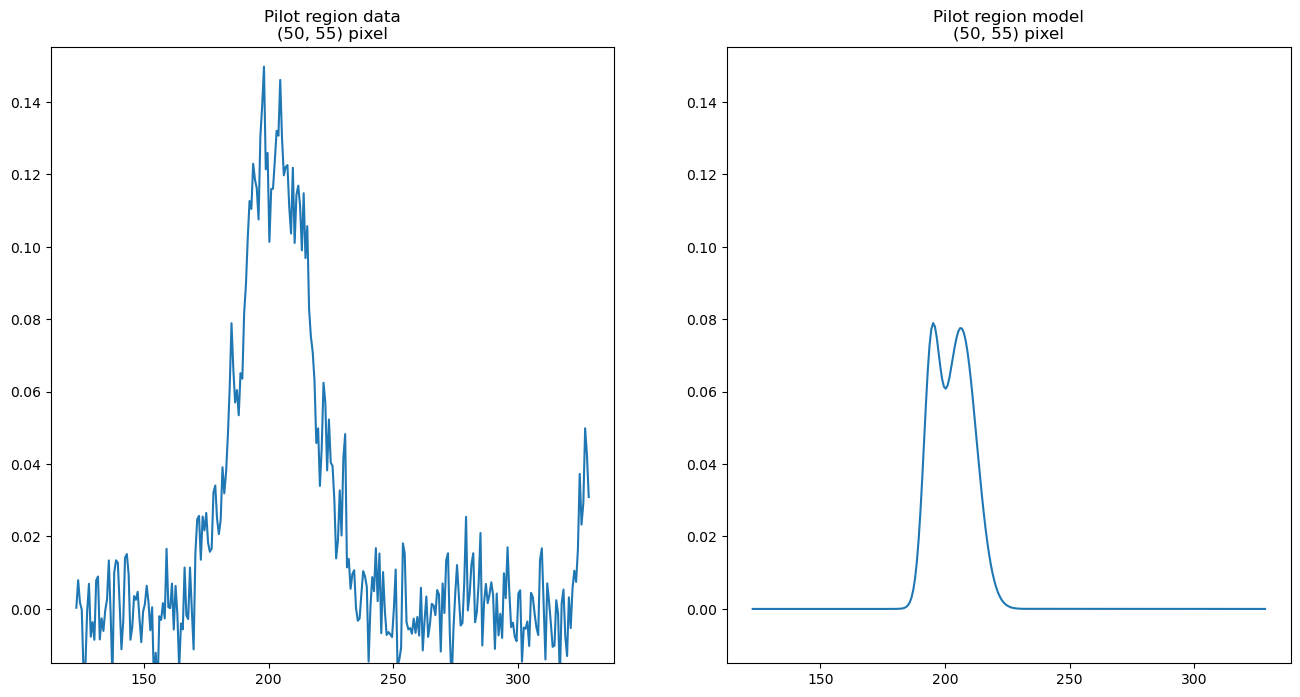

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_figwidth(16)
fig.set_figheight(8)

ax1.plot(Cube[:, 55, 50].spectral_axis, Cube[:, 55, 50])
ax1.set_title('Pilot region data\n(50, 55) pixel')
ax1.set_ylim(-.015, 0.155)

ax2.plot(model[:, 55, 50].spectral_axis, model[:, 55, 50])
ax2.set_title('Pilot region model\n(50, 55) pixel')
ax2.set_ylim(-.015, 0.155)

plt.show()